<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [180]:
#Importation de la librairie Pandas
import pandas as pd

In [181]:
#Importation de la librairie plotly express
import seaborn as sns
import matplotlib.pyplot as plt

#matplotlib.pyplot est nécessaire techniquement pour afficher une heatmap Seaborn afin de gérer :
# la taille
# le titre
# l’affichage


In [182]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [183]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("/content/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("/content/erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("/content/liaison.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [184]:
#Afficher les dimensions du dataset
print("→ Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("→ Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

→ Le tableau comporte 825 observation(s) ou article(s)
→ Le tableau comporte 6 colonne(s)


In [185]:
# Consulter le nombre de colonnes
print("Nombre de colonnes :", df_erp.shape[1])
print('\n')

# La nature des données dans chacune des colonnes
# Le nombre de valeurs présentes dans chacune des colonnes


df_erp.info()


Nombre de colonnes : 6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [186]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [187]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp["product_id"].duplicated().any()
if df_erp["product_id"].duplicated().any() == False :
  print("aucun doublon")
else :
  print("il y a des doublons")


aucun doublon


In [188]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp["stock_status"].unique()


array(['instock', 'outofstock'], dtype=object)

In [189]:
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp[["product_id","onsale_web","stock_quantity"]].head(5)

,product_id,onsale_web,stock_quantity
0,3847,1,16
1,3849,1,10
2,3850,1,0
3,4032,1,26
4,4039,1,3


In [190]:
print("Incohérences entre les stocks et les statut")
print('___________________________________________\n')
df_erp.loc[
    (
        (df_erp["stock_quantity"] <= 0) &
        (df_erp["stock_status"] != "outofstock")
    ) |
    (
       (df_erp["stock_quantity"] > 0) &
       (df_erp["stock_status"] != "instock")
    ),
    ["product_id","stock_quantity","stock_status"]

]


Incohérences entre les stocks et les statut
___________________________________________



,product_id,stock_quantity,stock_status
4,4039,3,outofstock
398,4885,0,instock


In [191]:
print("produits proposés à la ventes mais en rupture")
print('___________________________________________\n')
df_erp.loc[
        (df_erp["onsale_web"] == 1) &
        (df_erp["stock_quantity"] <= 0 )
    ]

produits proposés à la ventes mais en rupture
___________________________________________



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
2,3850,1,20.80,0,outofstock,10.64
8,4043,1,60.00,0,outofstock,29.45
11,4047,1,18.30,0,outofstock,9.93
15,4051,1,7.70,0,outofstock,4.14
16,4052,1,33.70,0,outofstock,18.11
28,4065,1,19.50,0,outofstock,9.67
42,4079,1,37.00,0,outofstock,19.50
57,4100,1,15.80,0,outofstock,8.57
70,4138,1,25.70,0,outofstock,13.01
106,4179,1,24.00,0,outofstock,13.02


In [192]:
print("produits non proposés à la ventes mais en stock")
print('___________________________________________\n')
df_erp.loc[
        (df_erp["onsale_web"] == 0) &
        (df_erp["stock_quantity"] > 0 )
    ]

produits non proposés à la ventes mais en stock
___________________________________________



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
123,4200,0,5.8,33,instock,3.12
234,4565,0,30.5,3,instock,15.92
238,4577,0,49.0,1,instock,24.05
239,4578,0,40.0,3,instock,20.05
318,4692,0,12.0,48,instock,6.39
...,...,...,...,...,...,...
818,7200,0,31.0,6,instock,15.54
819,7201,0,31.0,18,instock,16.02
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18


In [193]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = None
df_erp.loc[df_erp["stock_quantity"] > 0, "stock_status_2"] = "instock"
df_erp.loc[df_erp["stock_quantity"] <= 0, "stock_status_2"] = "outofstock"
df_erp


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


In [194]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp[df_erp["stock_status_2"] != df_erp["stock_status"]]

# note Thomas : j'utilise l'attribut loc pour plus de lisibilité et comme bonne pratique → syntaxe : loc(lignes,colonnes)
df_erp.loc[                                             #début de l'attribut
    df_erp["stock_status_2"] != df_erp["stock_status"], #lignes à retenir
    ["product_id", "stock_status", "stock_status_2"]    #colonnes à afficher
]                                                       #fin de l'attribut


#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,product_id,stock_status,stock_status_2
4,4039,outofstock,instock
398,4885,instock,outofstock


In [195]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 823 qui correspond au nombre de lignes dans ce dataset
tableau = {
    "statuts conformes" : int((df_erp["stock_status_2"] == df_erp["stock_status"]).sum()),
    "statuts non conformes" : int((df_erp["stock_status_2"] != df_erp["stock_status"]).sum())
}

tableau

{'statuts conformes': 823, 'statuts non conformes': 2}

In [196]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [197]:
#Corriger la ou les données incohérentes
df_erp.loc[
    df_erp["stock_status"] != df_erp["stock_status_2"],
    "stock_status"
] = df_erp["stock_status_2"]

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
nb_erreur = int((df_erp["stock_status"] != df_erp["stock_status_2"]).sum())
print('il y a actuellement',nb_erreur,' erreur(s)')

il y a actuellement 0  erreur(s)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [198]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?

tableau2 = pd.DataFrame(
    {
        "Anomalies sur les prix" : ["Prix non renseignés","Prix nuls ou négatifs"],
        "Nombre de lignes" : [
   df_erp["price"].isna().sum(), (df_erp["price"] <= 0).sum()
        ]
}
)

tableau2


,Anomalies sur les prix,Nombre de lignes
0,Prix non renseignés,0
1,Prix nuls ou négatifs,3


In [199]:
#Afficher le ou les prix non renseignés dans la colonne "price"
#Saisir l'instruction manquante dans la fonction format
print(
    "Nombres d'articles avec un prix non renseigné: {}".format(
        df_erp["price"].isna().sum())
)

df_erp.loc[
    df_erp["price"].isna(),
    ["product_id","price"]
    ]


Nombres d'articles avec un prix non renseigné: 0


,product_id,price


In [200]:
#Afficher le prix minimum de la colonne "price"
df_erp["price"].min()

-20.0

In [201]:
#Afficher le prix maximum de la colonne "price"
df_erp["price"].max()

225.0

In [202]:
#Afficher les prix inférieurs à 0
df_erp.loc[
    df_erp["price"] < 0,["product_id","price"]
    ]

,product_id,price
151,4233,-20.0
469,5017,-8.0
739,6594,-9.1


In [203]:
#qu'est-ce qu'il faut en faire ?

print("il faut corriger ces prix et les retirer immédiatement de la vente si elles sont proposées à la vente")

# code → df_erp.loc[df_erp["price"] <= 0,"onsale_web"] = 0
# néanmoins les lignes concernées ont déjà pour valeurs onsale_web = 0


il faut corriger ces prix et les retirer immédiatement de la vente si elles sont proposées à la vente


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [204]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
df_erp["stock_quantity"].min()


-10

In [205]:
#Afficher la quantité maximum de la colonne "stock_quantity"
df_erp["stock_quantity"].max()

145

In [206]:
#Afficher les stocks inférieurs à 0
df_erp.loc[
    df_erp["stock_quantity"] < 0,["product_id","stock_quantity"]
        ]

,product_id,stock_quantity
449,4973,-10
573,5700,-1


In [207]:
#(qu'est-ce qu'il faut en faire ?)
print("Vérifier le stock réel pour ces articles et faire la correction informatique. Chercher également d'où provient l'erreur.")

Vérifier le stock réel pour ces articles et faire la correction informatique. Chercher également d'où provient l'erreur.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [208]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient.
df_erp["onsale_web"].unique()


array([1, 0])

In [209]:
#Que signifient-elles ?
signification = pd.DataFrame(
    {
        "Signification" : ["produit en vente via le site web","produit non vendu sur le site web"],
        "Valeur" : [1,0]
    }
)

signification



,Signification,Valeur
0,produit en vente via le site web,1
1,produit non vendu sur le site web,0


In [210]:
#Quelles sont les colonnes à conserver selon vous?


In [211]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=["stock_status_2"])
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [212]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp.loc[df_erp["purchase_price"].isna(),["product_id","purchase_price"]]


,product_id,purchase_price


In [213]:
#Afficher le prix minimum de la colonne "purchase_price"
df_erp.loc[
    df_erp["purchase_price"] == df_erp["purchase_price"].min(),
    ["product_id","purchase_price"]
]

# Thomas : permet d'afficher les articles dans le cas où il y en aurait plusieurs au prix minimum.


,product_id,purchase_price
700,6129,2.74


In [214]:
#Afficher le prix maximum de la colonne "purchase_price"

df_erp.loc[
    df_erp["purchase_price"] == df_erp["purchase_price"].max(),
    ["product_id","purchase_price"]
]

# Thomas : permet d'afficher les articles dans le cas où il y en aurait plusieurs au prix maximum.

,product_id,purchase_price
208,4352,137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [215]:
#Dimension du dataset
#Nombre de caractéristiques
#Nombre d'observations
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

df_web.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [216]:
#Selon vous, quelles sont les colonnes à conserver ?
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
liste_des_colonnes_a_supprimer = ["tax_class", "post_content", "post_password", "post_content_filtered","virtual","downloadable","rating_count","average_rating"]
for col in liste_des_colonnes_a_supprimer:
    df_web.drop(col, axis=1, inplace=True)



In [217]:
#Visualisation des valeurs de la colonne sku

df_web["sku"].unique()



array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [218]:
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
df_web.loc[
           (df_web["sku"].notna()) &
           (pd.to_numeric(df_web["sku"], errors="coerce").isna()),
           "sku"
].drop_duplicates()


,sku
272,13127-1
842,bon-cadeau-25-euros


In [219]:
#Identifier les lignes sans code article
df_web.loc[df_web["sku"].isnull(),"sku"]

,sku
8,NaN
20,NaN
30,NaN
37,NaN
41,NaN
...,...
1384,NaN
1429,NaN
1432,NaN
1445,NaN


In [220]:
# Mise à jour du dataframe df_web pour retirer les lignes sans "sku"
df_web["sku"].value_counts().gt(1).sum()
print("il y a ",df_web["sku"].value_counts().gt(1).sum()," sku en double")



il y a  714  sku en double


In [221]:
# je nettoie les lignes vides (sans "sku")
df_web = df_web[df_web["sku"].notnull()].copy()
print("Nb de lignes initial : 1513 lignes","\nNb de lignes vides : 85","\nNombre de doublons : 714","\nNb de lignes du Dataframe au final : 714")

Nb de lignes initial : 1513 lignes 
Nb de lignes vides : 85 
Nombre de doublons : 714 
Nb de lignes du Dataframe au final : 714


In [222]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
df_web[df_web["post_type"] == "product"]


,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
2,14692,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,"<div>Grâce à la complémentarité des 3 cépages qui le constituent, Le Cygne est un vin complet, élégant et aérien, offrant une riche palette aromatique fruitée et florale, une rondeur en bouche avec des saveurs suaves.</div>",publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=5794,0.0,product,NaN,0.0
4,15328,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: transparent; color: #000000; font-family: 'Open Sans',Arial,Verdana,sans-serif; font-size: 15px; font-style: normal; font-variant: normal; font-weight: 400; letter-spacing: normal; list-style-type: none; text-align: center; text-decoration: none; text-indent: 0px;"">C’est un vin élégant et délicat caractéristique du lieu-dit La Landonne, aux arômes fruités complété par des notes florales de violette et soutenu par le velours des tanins très fins et fermes.</span>\n\n&nbsp;",publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=5827,0.0,product,NaN,0.0
6,16515,10.0,taxable,2.0,2018-06-02 09:31:31,2018-06-02 07:31:31,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,"<div id=""wrapper"">\n<div id=""container-wrapper"">\n<div id=""content-wrapper"">\n<div class=""contenu""><section id=""vue"">\n<div class=""wysiwyg"">\n\n<span style=""float: none; background-color: transparent; color: #454545; font-family: 'Helvetica Neue',Helvetica,Roboto,Arial,sans-serif; font-size: 16px; font-style: normal; font-variant: normal; font-weight: 400; letter-spacing: normal; line-height: 25.6px; text-align: left; text-decoration: none; text-indent: 0px;"">Fruit rouge bien mûr, un côté épicé, fumé et grillé, lié au terroir et à l’élevage en barriques.</span> <span style=""float: none; background-color: transparent; color: #454545; font-family: 'Helvetica Neue',Helvetica,Roboto,Arial,sans-serif; font-size: 16px; font-style: normal; font-variant: normal; font-weight: 400; letter-spacing: normal; line-height: 25.6px; text-align: left; text-decoration: none; text-indent: 0px;"">Riche, concentrée, charnue et mûre, avec de la fraîcheur. L’élevage en barriques permet aux tanins de bien se fondre et apporte de la rondeur.</span>\n\n</div>\n</section></div>\n</div>\n</div>\n</div>\n<footer>\n<div id=""footer-wrapper"">\n<div id=""footer-container""></div>\n</div>\n</footer>",publish,closed,closed,chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018,2020-08-27 10:11:12,2020-08-27 08:11:12,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=4964,0.0,product,NaN,0.0
11,16585,15.0,taxable,2.0,2018-02-16 14:03:16,2018-02-16 13:03:16,Vin,Xavier Frissant Touraine Sauvignon 2019,"Un joli sauvignon frais et minéral, avec d'intenses notes exotiques. Des très beaux produits à petit prix.",publish,closed,closed,xavier-frissant-touraine-sauvignon-2019,2020-08-27 09:30:36,2020-08-27 07:30:36,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=4223,0.0,product,NaN,0.0
14,12869,7.0,taxable,2.0,2019-03-28 14:29:35,2019-03-28 13:29:35,Vin,Stéphane Tissot Arbois D.D. 2016,"Un Vin coloré et éclatant. Le nez est fruité, aux arômes de griotte et de prunelle, accompagné d'épices douces. La bouche est pure et fruitée, disposant beaux tanins souples et élégants.",publish,closed,closed,stephane-tissot-arbois-dd-2016,2019-12-13 15:40:01,2019-12-13 14:40:01,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=5900,0.0,product,NaN,0.0
...,...,...,...,...,...,...,...,.

In [223]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
if df_web["sku"].duplicated().any() == True : print("Oui, il y a des doublons\nCes derniers sont dus au fait que chaque article a 2 lignes dans la base")
else : print("il n'y a pas de doublons")



Oui, il y a des doublons
Ces derniers sont dus au fait que chaque article a 2 lignes dans la base


In [224]:
# je supprime les lignes en doublons liées aux images ("attachment")
df_web_products = df_web[df_web["post_type"] == "product"].copy()

In [225]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web[df_web["sku"].isnull()]

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web[df_web["sku"].isnull()].info()

#3 - Que constatez-vous?

    # 1. les valeurs 0 sont présentes dans les  colonnes 'virtual','dowloadable', 'rating count'
    # 2. 2 articles n'ont pas de SKU et affichent des ventes négatives.
          # Pierre Jean Villa Condrieu Jardin Suspendu 2018
          # Pierre Jean Villa Côte Rôtie Fongeant 2017

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   total_sales        0 non-null      float64       
 2   tax_status         0 non-null      object        
 3   post_author        0 non-null      float64       
 4   post_date          0 non-null      datetime64[ns]
 5   post_date_gmt      0 non-null      datetime64[ns]
 6   product_type       0 non-null      object        
 7   post_title         0 non-null      object        
 8   post_excerpt       0 non-null      object        
 9   post_status        0 non-null      object        
 10  comment_status     0 non-null      object        
 11  ping_status        0 non-null      object        
 12  post_name          0 non-null      object        
 13  post_modified      0 non-null      datetime64[ns]
 14  post_modified_gmt  0 non-nu

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [226]:
#Dimension du dataset:

#Nombre d'observations
#Nombre de caractéristiques
print("le dataset contient ",df_liaison.shape[0]," lignes et ",df_liaison.shape[1]," colonnes")
print("il s'agit d'une table de correspondance pour faire le lien entre les données issues de l'erp et celles issues du site web")



le dataset contient  825  lignes et  2  colonnes
il s'agit d'une table de correspondance pour faire le lien entre les données issues de l'erp et celles issues du site web


In [227]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

df_liaison.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [228]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
if df_liaison["product_id"].duplicated().any() : print("Non, il y a des doublons")
else : print("Oui, chaque valeur est unique")


Oui, chaque valeur est unique


In [229]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
if df_liaison["id_web"].dropna().is_unique == True : print("Oui, chaque valeur est unique")
else : print("Non, il y a des doublons")



Oui, chaque valeur est unique


In [230]:
#Avons-nous des articles sans correspondance?
if df_liaison["id_web"].isna().any() == True : print(df_liaison["id_web"].isna().sum()," lignes n'ont pas de valeur")
else: print("non, tout va bien de ce côté-là")

91  lignes n'ont pas de valeur


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [231]:
#Fusion des fichiers df_erp et df_liaison

df_merge = df_erp.merge(
    df_liaison,
    on="product_id",
    how="outer",
    indicator=True
)

df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN,both
821,7204,0,45.0,9,instock,24.18,NaN,both
822,7247,1,54.8,6,instock,27.18,13127-1,both
823,7329,0,26.5,14,instock,13.42,14680-1,both


In [232]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   product_id      825 non-null    int64   
 1   onsale_web      825 non-null    int64   
 2   price           825 non-null    float64 
 3   stock_quantity  825 non-null    int64   
 4   stock_status    825 non-null    object  
 5   purchase_price  825 non-null    float64 
 6   id_web          734 non-null    object  
 7   _merge          825 non-null    category
dtypes: category(1), float64(2), int64(3), object(2)
memory usage: 46.2+ KB


In [233]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?



df_merge.loc[df_merge["_merge"] != "both"]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge


In [234]:
df_merge.drop("_merge",axis=1,inplace=True)


In [235]:
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN
821,7204,0,45.0,9,instock,24.18,NaN
822,7247,1,54.8,6,instock,27.18,13127-1
823,7329,0,26.5,14,instock,13.42,14680-1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [236]:
#Fusionner les datasets df_merge et df_web
df_final = df_merge.merge(
    df_web_products,
    left_on="id_web",
    right_on="sku",
    how="outer",
    indicator=True)

df_base_finale = df_final.copy()

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         825 non-null    int64         
 1   onsale_web         825 non-null    int64         
 2   price              825 non-null    float64       
 3   stock_quantity     825 non-null    int64         
 4   stock_status       825 non-null    object        
 5   purchase_price     825 non-null    float64       
 6   id_web             734 non-null    object        
 7   sku                714 non-null    object        
 8   total_sales        714 non-null    float64       
 9   tax_status         714 non-null    object        
 10  post_author        714 non-null    float64       
 11  post_date          714 non-null    datetime64[ns]
 12  post_date_gmt      714 non-null    datetime64[ns]
 13  product_type       713 non-null    object        
 14  post_title

In [237]:
df_final.loc[
    df_final["_merge"] != "both"
]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
81,4741,0,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
127,5957,0,39.0,0,outofstock,20.75,13577,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
139,4289,0,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
180,4869,0,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
185,5955,0,27.3,0,outofstock,13.68,14377,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [238]:
#Avons-nous des lignes sans correspondance?
if df_final["sku"].isna().any() == True : print("Oui, il y a ",df_final["sku"].isna().sum()," product_id sans correspondance (sans sku)")
else : print("Non, tous les product_id ont bien un sku")

Oui, il y a  111  product_id sans correspondance (sans sku)


In [239]:
df_final[df_final["sku"].isna()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
81,4741,0,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
127,5957,0,39.0,0,outofstock,20.75,13577,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
139,4289,0,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
180,4869,0,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
185,5955,0,27.3,0,outofstock,13.68,14377,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [240]:

# Thomas : on remarque que 20 produits présents dans la liste fusionnés ont bien un product_id avec un id_web mais cet id_web ne se retrouvent pas dans le dataframe _df_web
# exemple la ligne 823 avec la reference produit '7329', qui a bien un sku/id_web mais ce dernier n'est pas présent.
df_final.loc[
    (df_final["sku"].isna())&
    (df_final["id_web"].notna()),
    ["product_id","id_web"]
    ]




,product_id,id_web
81,4741,12601
127,5957,13577
139,4289,13771
180,4869,14360
185,5955,14377
186,5953,14379
212,5505,14648
218,5800,14689
224,5559,14715
227,5570,14730


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

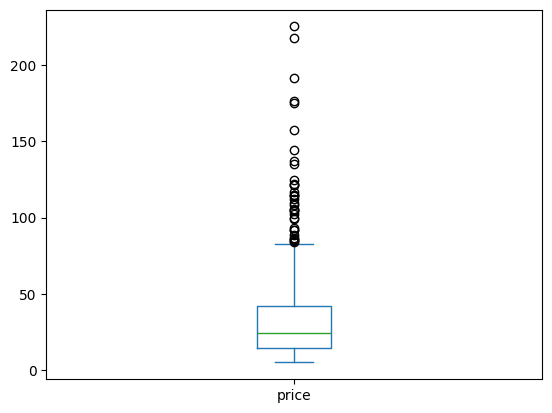

In [241]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas

df_final.loc[df_final["price"] > 0, "price"].plot.box()


In [242]:
#Autre méthode avec plotly express
import plotly.express as px
px.box(
    df_final[df_final["price"] > 0],
    y="price",
    title="Répartition des prix (boxplot)",
    labels={"price": "Prix (€)"}
)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [243]:
#Calculer la moyenne du prix

moyenne = df_final.loc[
    (df_final["price"]>0)&
    (df_final["price"].notna()),
    "price"
    ].mean()

print("Moyenne : ",round(moyenne,2))




Moyenne :  32.35


In [244]:
# Thomas : Aperçu des prix erronnés

liste_prix_erronnés = df_final[df_final["price"]<=0]
liste_prix_erronnés

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
739,4233,0,-20.0,0,outofstock,10.33,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
760,5017,0,-8.0,0,outofstock,4.34,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
772,6594,0,-9.1,19,instock,4.61,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [245]:
#Calculer l'écart-type du prix

Ecart_type = df_final.loc[
    (df_final["price"]>0)&(df_final["price"].notna()),"price"].std()


print("Ecart-type : ",round(Ecart_type,2))

Ecart-type :  26.62


In [246]:
#Calculer le Z-score
# Thomas : Le Z-score mesure à quelle distance de la moyenne se trouve chaque prix, en nombre d’écarts-types.
# (Prix - moyenne) / Ecart-Type


# Puis je calcule le z-score
df_final["z_score"] = round(((df_final["price"] - moyenne) / Ecart_type),2)
df_final.head()

# Pour simplifier j'exclue définitivement les 3 lignes qui peuvent biaiser le calcul (prix erronnés ou prix vide), avant de calculer le Z-score

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge,z_score
0,4729,1,8.6,26,instock,4.22,38,38,10.0,taxable,2.0,2018-04-18 12:25:58,2018-04-18 10:25:58,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,"Ce Crémant est vif et délicat, gourmand et croquant avec une bulle dynamique. Un excellent rapport qualité-prix.",publish,closed,closed,emile-boeckel-cremant-brut-blanc-de-blancs,2020-08-27 17:15:03,2020-08-27 15:15:03,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=4729,0.0,product,NaN,0.0,both,-0.89
1,4634,1,41.0,11,instock,20.12,41,41,6.0,taxable,2.0,2018-04-14 12:01:43,2018-04-14 10:01:43,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurztraminer,"Les eaux de vie naissent d'une subtile alchimie où deux éléments fondamentaux se conjuguent pour que la réussite soit présente au creux de votre verre à dégustation... D'abord on ne s'improvise pas distillateur: chez les Windholtz ce sont trois générations qui ont accumulé le plein d'expérience dans l'art subtil de ""séparer par la chaleur les principes fixes et volatiles"".\nEnsuite entre moûts et alambic au long col, au milieu des vapeurs, c'est le savoir-faire qui préside à la transmutation mystérieuse et réfléchie destinées à sublimer et à faire chanter les fruits...",publish,closed,closed,marcel-windholtz-eau-de-marc-de-gewurztraminer,2020-08-03 10:25:02,2020-08-03 08:25:02,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=4634,0.0,product,NaN,0.0,both,0.32
2,4141,1,39.0,123,instock,24.86,304,304,8.0,taxable,2.0,2018-02-13 12:57:44,2018-02-13 11:57:44,Champagne,Champagne Gosset Grande Réserve,"Le nez, ouvert et expressif, évoque les fruits rouges mûrs (cassis), le froment, les fruits secs, le pain d’épice, la confiture de vieux garçon...La bouche est dominée par une tension minérale rafraîchissante associée à un goût chaleureux et consistant faisant écho à la richesse et au charnu du vin. Sous une expression dense de fruits mûrs et secs, apparaît en filigrane une fraîcheur discrète. Une ossature subtile et racée, signature des champagnes Gosset.",publish,closed,closed,gosset-champagne-grande-reserve,2020-08-27 11:25:02,2020-08-27 09:25:02,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=4141,0.0,product,NaN,0.0,both,0.25
3,5932,1,59.9,13,instock,27.18,523,523,0.0,taxable,2.0,2019-04-06 15:25:58,2019-04-06 13:25:58,Cognac,Cognac Normandin Mercier VFC,"Issus des meilleurs crus de Grande et de Petite Champagne, ces cognacs sont sélectionnés avec la plus grande exigence, puis élevés dans les chais traditionnels aux portes de La Rochelle. Vieille Fine Champagne, douce et équilibrée avec un agréable bouquet floral.\n\n&nbsp;",publish,closed,closed,cognac-normandin-mercier-vfc,2020-08-12 16:45:03,2020-08-12 14:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=5932,0.0,product,NaN,0.0,both,1.03
4,5047,1,22.5,76,instock,13.78,531,531,8.0,taxable,2.0,2018-07-18 15:58:02,2018-07-18 13:58:02,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Blancs Grand Cru,"Cuvée bien équilibrée à la fois vive et souple, l'attaque en bouche est franche, droite. La bouche est légère, complexe et consistante, alliant souplesse et vigueur. La finale est rémanente, longue. L'ensemble de la dégustation laisse des impressions de fraîcheur, de gras.",publish,closed,closed,champagne-petit-lebrun-fils-blanc-de-blancs-grand-cru,2020-08-27 15:35:03,2020-08-27 13:35:03,0.0,https://www.bottle-neck.fr/?post_type=product&#038;p=5047,0.0,product,NaN,0.0,both,-0.37


In [247]:
#Quel est le seuil prix dont le z-score est supérieur à 3?

#Thomas : Le seuil de prix correspondant à un Z-score supérieur à 3
      # est égal à la moyenne augmentée de trois fois l’écart-type.
      # Les produits dont le prix dépasse ce seuil peuvent être considérés comme des valeurs "éloignées de la moyenne".

seuil_prix = moyenne + 3 * Ecart_type
print("prix seuil : ",round(seuil_prix,2))



prix seuil :  112.22


In [248]:
# Affiche des articles avec le Z-score :

df_final.loc[
    df_final["price"] > seuil_prix,
    ["product_id", "post_title", "price", "purchase_price","z_score"]
]

,product_id,post_title,price,purchase_price,z_score
24,4402,Cognac Frapin VIP XO,176.0,78.25,5.40
33,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,157.0,69.08,4.68
87,6215,Domaine des Comtes Lafon Volnay 1er Cru Champans 2014,115.0,56.45,3.10
157,6212,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,115.0,59.42,3.10
171,4904,Domaine Des Croix Corton Charlemagne Grand Cru 2016,137.0,67.95,3.93
204,5001,David Duband Charmes-Chambertin Grand Cru 2014,217.5,116.87,6.95
233,5918,Wemyss Malts Single Cask Scotch Whisky Chai Caramel Latte 2002 Craigellachie,114.0,52.25,3.07
235,5917,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,122.0,54.24,3.37
256,5612,Domaine Weinbach Gewurztraminer Grand Cru Furstentum SGN 2010 1/2,124.8,66.41,3.47
257,6126,Champagne Gosset Célébris Vintage 2007,135.0,80.33,3.86


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [249]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_final_describe = df_final["price"].describe()
df_final_describe

,price
count,825.000000
mean,32.187697
std,26.712077
min,-20.000000
25%,14.500000
50%,24.300000
75%,42.000000
max,225.000000


In [250]:
#Définir un seuil pour les articles "outliers" en prix

seuil_outliers = df_final_describe.loc['75%'] + (df_final_describe.loc['75%'] - df_final_describe.loc['25%']) * 1.5
print("Seuil : ",seuil_outliers)

Seuil :  83.25


In [251]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

nb_total_articles = len(df_final)
print("Nombre total d'articles : ",nb_total_articles)

nb_articles_outliers = len(df_final[df_final["price"] > seuil_outliers])
print("Nombre d'articles en outliers : ",nb_articles_outliers)

proportion_outliers = nb_articles_outliers / nb_total_articles
print("Proportion d'articles en outliers : ",round(proportion_outliers * 100,2),"%")


Nombre total d'articles :  825
Nombre d'articles en outliers :  36
Proportion d'articles en outliers :  4.36 %


In [252]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
df_final.loc[df_final["price"] > seuil_outliers, ["product_id","post_title","total_sales","onsale_web","stock_quantity","purchase_price","price","z_score"]]


#Ces outliers correspondent aux articles dont les prix sont les plus élevés.
#Ils se situent donc naturellement dans la liste des articles qui ont un z-score à supérieur à 3.
#Au regard de la marge commerciale appliquée, celle-ci est identique aux autres articles qui sont en vente.
# Voir si pour ces articles la même marge commerciale doit être conservée (env 50%), la marge en % est à mon sens trop élevé, la marge en € est très bonne sur la vente d'un de ces articles).


,product_id,post_title,total_sales,onsale_web,stock_quantity,purchase_price,price,z_score
22,4404,Cognac Frapin Château de Fontpinot XO,4.0,1,17,52.22,108.5,2.86
23,4407,Cognac Frapin Cigar Blend,5.0,1,14,46.71,104.0,2.69
24,4402,Cognac Frapin VIP XO,3.0,1,11,78.25,176.0,5.40
33,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,4.0,1,12,69.08,157.0,4.68
53,6214,Domaine des Comtes Lafon Volnay 1er Cru Champans 2013,6.0,1,9,49.62,99.0,2.50
54,5008,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,7.0,1,12,56.42,105.0,2.73
56,4132,Zind-Humbrecht Pinot Gris Grand Cru Rangen De Thann Clos Saint-Urbain 2012,5.0,1,7,44.30,88.4,2.11
87,6215,Domaine des Comtes Lafon Volnay 1er Cru Champans 2014,4.0,1,14,56.45,115.0,3.10
88,5007,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2014,3.0,1,15,55.88,105.0,2.73
89,4582,Château de Meursault Puligny-Montrachet 1er Cru Champ Canet 2014,1.0,1,18,53.80,109.6,2.90


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [253]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_final["ca_article"] = df_final["price"] * df_final["total_sales"]
df_final[["product_id","post_title","total_sales","price","ca_article"]].head()

#Calculer la somme de la colonne "ca_par_article"
print(df_final["ca_article"].sum()," €")

#Ce résultat correspond au chiffre d'affaire du site web


143680.1  €


In [254]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_final = df_final.sort_values(by="ca_article", ascending=False)


#Réinitialiser l'index du dataset par un reset_index
df_final = df_final.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
df_final[["product_id", "post_title", "total_sales", "ca_article"]].head(20)





,product_id,post_title,total_sales,ca_article
0,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11.0,2475.0
1,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,6.0,1147.8
2,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,14.0,1113.0
3,5826,Agnès Levet Côte Rôtie Améthyste 2017,20.0,824.0
4,6212,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,7.0,805.0
5,5026,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,9.0,781.2
6,5008,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,7.0,735.0
7,5767,Camille Giroud Clos de Vougeot 2016,4.0,700.0
8,6126,Champagne Gosset Célébris Vintage 2007,5.0,675.0
9,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,6.0,672.0


In [255]:
#Graphique en barre des 20 premiers articles avec plotly express


top_20 = df_final.nlargest(20, "ca_article")[["product_id", "post_title", "ca_article"]]

fig = px.bar(
    top_20.sort_values("ca_article"),
    x="ca_article",
    y="post_title",
    orientation="h",
    title="Top 20 des articles par chiffre d'affaires",
    height=800
)

fig.update_layout(
    yaxis_title="Article",
    xaxis_title="CA (€)",
    bargap=0.18,
    margin=dict(l=250, r=30, t=60, b=30)  # plus de place pour les libellés à gauche
)

fig.show()


In [256]:
#Ajout Thomas pour présentation - CA par catégorie
ca_par_categorie = (
    df_final
    .groupby("product_type")["ca_article"]
    .sum()
    .reset_index()
    .sort_values("ca_article",ascending=True)
)

fig = px.bar(
    ca_par_categorie,
    x="ca_article",
    y="product_type",
    orientation="h",
    title="Chiffre d'affaires par catégorie"
)

fig.show()


In [257]:
#Ajout Thomas : Quantités vendues par catégorie
qte_par_categorie = (
    df_final
    .groupby("product_type")["total_sales"]
    .sum()
    .reset_index()
    .sort_values("total_sales",ascending=True)
)

fig = px.bar(
    qte_par_categorie,
    x="total_sales",
    y="product_type",
    orientation="h",
    title="Quantités vendues par catégorie"
)

fig.show()


In [258]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset

ca_total = df_final["ca_article"].sum()
df_final["part_ca"] = df_final["ca_article"] / ca_total

df_final.loc[
    :,
     ["product_id", "post_title", "ca_article", "part_ca"]].head(20)




,product_id,post_title,ca_article,part_ca
0,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,0.017226
1,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,1147.8,0.007989
2,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,0.007746
3,5826,Agnès Levet Côte Rôtie Améthyste 2017,824.0,0.005735
4,6212,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,805.0,0.005603
5,5026,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,781.2,0.005437
6,5008,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,735.0,0.005116
7,5767,Camille Giroud Clos de Vougeot 2016,700.0,0.004872
8,6126,Champagne Gosset Célébris Vintage 2007,675.0,0.004698
9,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,672.0,0.004677


In [259]:
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

df_final["part_ca_cumulee"] = df_final["part_ca"].cumsum()

df_final.loc[
    :,
     ["post_title", "ca_article", "part_ca","part_ca_cumulee"]].head(20)


,post_title,ca_article,part_ca,part_ca_cumulee
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,0.017226,0.017226
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,1147.8,0.007989,0.025214
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,0.007746,0.032961
3,Agnès Levet Côte Rôtie Améthyste 2017,824.0,0.005735,0.038696
4,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,805.0,0.005603,0.044298
5,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,781.2,0.005437,0.049735
6,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,735.0,0.005116,0.054851
7,Camille Giroud Clos de Vougeot 2016,700.0,0.004872,0.059723
8,Champagne Gosset Célébris Vintage 2007,675.0,0.004698,0.064421
9,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,672.0,0.004677,0.069098


In [260]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

nb_articles_total = df_final.shape[0] # → Nb d'article au total
print("Nombre d'articles total : ",nb_articles_total)


#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web

articles_80 = df_final.loc[df_final["part_ca_cumulee"] < 0.8]   # → J'isole les 80%
nb_articles_80 = articles_80.shape[0]

proportion_articles_80 = nb_articles_80 / nb_articles_total # → Je calcule la proportion
proportion_articles_80_pct = round(proportion_articles_80 * 100, 2) # → Je transforme en pourcentage

print(nb_articles_80," articles permettent d’atteindre 80 % du chiffre d’affaires, ce qui représente",proportion_articles_80_pct,"% de l’ensemble du catalogue du site web.")



Nombre d'articles total :  825
434  articles permettent d’atteindre 80 % du chiffre d’affaires, ce qui représente 52.61 % de l’ensemble du catalogue du site web.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [261]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge

df_final_par_qte_vendue = df_final.sort_values(by="total_sales", ascending=False)
df_final_par_qte_vendue[["product_id", "post_title", "total_sales"]].head(20)

#Réinitialiser l'index du dataset par un reset_index
df_final_par_qte_vendue = df_final_par_qte_vendue.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
df_final_par_qte_vendue[["product_id", "post_title", "total_sales"]].head(20)




,product_id,post_title,total_sales
0,4867,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,36.0
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,27.0
2,4275,I Fabbri Chianti Classico Lamole 2017,24.0
3,4726,François Baur Pinot Noir Schlittweg 2017,22.0
4,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,20.0
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,20.0
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,18.0
8,5803,Château Tour Haut-Caussan Médoc 2015,17.0
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,17.0


In [262]:
#Graphique en barre des 20 premiers articles avec plotly express


top_20_total_sales = df_final_par_qte_vendue.nlargest(20, "total_sales")[["product_id", "post_title", "total_sales"]]

histo_qte = px.bar(
    top_20_total_sales.sort_values("total_sales"),
    x="total_sales",
    y="post_title",
    orientation="h",
    title="Top 20 des articles par quantité vendue",
    height=800
)

histo_qte.update_layout(
    yaxis_title="Article",
    xaxis_title="Qté",
    bargap=0.18,
    margin=dict(l=250, r=30, t=60, b=30)  # plus de place pour les libellés à gauche
)

histo_qte.show()

In [263]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset

qte_total = df_final_par_qte_vendue["total_sales"].sum()
df_final_par_qte_vendue["Part_qte_totale"] = df_final_par_qte_vendue["total_sales"] / ca_total

df_final_par_qte_vendue.loc[:,["product_id", "post_title", "total_sales", "Part_qte_totale"]].head(20)




,product_id,post_title,total_sales,Part_qte_totale
0,4867,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,36.0,0.000251
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,27.0,0.000188
2,4275,I Fabbri Chianti Classico Lamole 2017,24.0,0.000167
3,4726,François Baur Pinot Noir Schlittweg 2017,22.0,0.000153
4,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,0.000153
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,20.0,0.000139
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,20.0,0.000139
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,18.0,0.000125
8,5803,Château Tour Haut-Caussan Médoc 2015,17.0,0.000118
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,17.0,0.000118


In [264]:
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

df_final_par_qte_vendue["Part_Cumul_Qte"] = df_final_par_qte_vendue["Part_qte_totale"].cumsum()
df_final_par_qte_vendue.loc[:,["product_id", "post_title", "Part_qte_totale","Part_Cumul_Qte"]].head(20)


,product_id,post_title,Part_qte_totale,Part_Cumul_Qte
0,4867,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,0.000251,0.000251
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,0.000188,0.000438
2,4275,I Fabbri Chianti Classico Lamole 2017,0.000167,0.000606
3,4726,François Baur Pinot Noir Schlittweg 2017,0.000153,0.000759
4,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,0.000153,0.000912
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,0.000139,0.001051
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,0.000139,0.001190
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,0.000125,0.001315
8,5803,Château Tour Haut-Caussan Médoc 2015,0.000118,0.001434
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,0.000118,0.001552


In [265]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

nb_articles_total = df_final_par_qte_vendue.shape[0] # → Nb d'article au total


#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web

Liste_articles_80 = df_final_par_qte_vendue.loc[df_final_par_qte_vendue["Part_Cumul_Qte"] < 0.8]   # → J'isole les 80%
nombre_articles_80 = Liste_articles_80.shape[0]

proportion_articles_80_ = nombre_articles_80 / nb_articles_total # → Je calcule la proportion
Prop_articles_80_pct = round(proportion_articles_80_ * 100, 2) # → Je transforme en pourcentage

print(nombre_articles_80," articles permettent d’atteindre 80 % du chiffre d’affaires, ce qui représente",Prop_articles_80_pct,"% de l’ensemble du catalogue du site web.")



714  articles permettent d’atteindre 80 % du chiffre d’affaires, ce qui représente 86.55 % de l’ensemble du catalogue du site web.


In [278]:
#Sous forme graphique :

# 1) Tri décroissant par CA
df_pareto = df_final_par_qte_vendue.sort_values("ca_article", ascending=False).copy()

# 2) Part de CA
df_pareto["part_ca"] = df_pareto["ca_article"] / df_pareto["ca_article"].sum()

# 3) Part cumulée
df_pareto["part_ca_cumulee"] = df_pareto["part_ca"].cumsum()

# (option) rang produit pour l’axe X
df_pareto["rang"] = range(1, len(df_pareto) + 1)

import plotly.graph_objects as go

fig = go.Figure()

# Barres : CA par article
fig.add_trace(
    go.Bar(
        x=df_pareto["rang"],
        y=df_pareto["ca_article"],
        name="CA par article"
    )
)

# Courbe : part cumulée du CA
fig.add_trace(
    go.Scatter(
        x=df_pareto["rang"],
        y=df_pareto["part_ca_cumulee"],
        name="Part cumulée du CA",
        mode="lines",
        yaxis="y2"
    )
)

# Ligne horizontale à 80%
fig.add_hline(y=0.8, line_dash="dash", opacity=0.6, yref="y2")

# Ligne verticale au point 80% (si tu veux)
fig.add_vline(x=nb_articles_80, line_dash="dash", opacity=0.6)
fig.update_layout(
    title="Pareto du CA (80/20)",
    xaxis_title="Produits (rang trié par CA décroissant)",
    yaxis_title="CA (€)",
    yaxis2=dict(
        title="Part cumulée du CA",
        overlaying="y",
        side="right",
        tickformat=".0%"
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    height=550
)



fig.show()



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [267]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np

#Création de la colonne Mois_en_vente
df_base_finale["post_date"] = pd.to_datetime(df_base_finale["post_date"]) # → Je m'assure que la date est bien au bon format
today = pd.Timestamp.today() # → Je m'assure que la date du jour soit au bon format
df_base_finale["mois_en_vente"] = round(((today - df_base_finale["post_date"]).dt.days / 30),1)   # → nb de mois en vente



In [268]:
moyenne_mois = df_base_finale["mois_en_vente"].mean()
round(moyenne_mois, 1)
print("les articles restent en vente en moyenne ",round(moyenne_mois,1)," en moyenne par article")

#Combien de mois peut-on vendre au rythme actuel avec le stock disponible ?
# 1. Calculer les ventes mensuelles moyennes

df_base_finale["ventes_mensuelles"] = (df_base_finale["total_sales"] / df_base_finale["mois_en_vente"])

# 2. Calculer le nombre de mois de stock
df_base_finale["mois_de_stock"] = (df_base_finale["stock_quantity"] / df_base_finale["ventes_mensuelles"])

# 3. Nettoyage des éventuelles mauvaises valeurs

df_base_finale["mois_de_stock"] = (df_base_finale["mois_de_stock"].replace([np.inf, -np.inf], np.nan))

# 4. Calcul de la couverture du stock au global

mois_stock_global = (df_base_finale["stock_quantity"].sum() /
     (df_base_finale["total_sales"].sum() / df_base_finale["mois_en_vente"].clip(lower=1, upper=12).mean())
)

print("la couverture de stock est de ",round(mois_stock_global,0)," mois")

les articles restent en vente en moyenne  90.5  en moyenne par article
la couverture de stock est de  37.0  mois


In [269]:
#Aperçu :
df_base_finale.loc[:,["product_id","post_title","stock_quantity","post_date","total_sales","onsale_web","mois_en_vente","ventes_mensuelles"]].head()


,product_id,post_title,stock_quantity,post_date,total_sales,onsale_web,mois_en_vente,ventes_mensuelles
0,4729,Emile Boeckel Crémant Brut Blanc de Blancs,26,2018-04-18 12:25:58,10.0,1,94.7,0.105597
1,4634,Marcel Windholtz Eau de Vie de Marc de Gewurztraminer,11,2018-04-14 12:01:43,6.0,1,94.8,0.063291
2,4141,Champagne Gosset Grande Réserve,123,2018-02-13 12:57:44,8.0,1,96.8,0.082645
3,5932,Cognac Normandin Mercier VFC,13,2019-04-06 15:25:58,0.0,1,82.9,0.000000
4,5047,Champagne Petit Lebrun &amp; Fils Blanc de Blancs Grand Cru,76,2018-07-18 15:58:02,8.0,1,91.6,0.087336


In [270]:

fig = px.histogram(
    df_base_finale,
    x="mois_en_vente",
    nbins=30,
    title="Distribution des mois en stock"
)

fig.update_layout(
    xaxis_title="Nombre de mois en stock",
    yaxis_title="Nombre d'articles"
)

fig.show()

In [271]:
# conversion en année pour meilleure visu
df_base_finale["annees_stock"] = (df_base_finale["mois_en_vente"] / 12).round(2)
fig = px.histogram(
    df_base_finale,
    x=df_base_finale["mois_en_vente"] / 12,
    nbins=30,
    title="Distribution des années de stock"
)

fig.update_layout(
    xaxis_title="Années de stock",
    yaxis_title="Nombre d'articles"
)
fig.show()


In [272]:

#Remplacement des "inf" par 0
df_base_finale["mois_en_vente"] = df_base_finale["mois_en_vente"].replace([np.inf, -np.inf], 0)
df_analyse_stock = df_base_finale.copy()


In [273]:
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
table_rotations = df_analyse_stock.loc[:,
 ["product_id","post_title","stock_quantity","total_sales","onsale_web","mois_en_vente"]
                     ].sort_values(by="mois_en_vente",ascending=False)


#Aperçu :
table_rotations = table_rotations.reset_index(drop=True)
table_rotations.head(20)

,product_id,post_title,stock_quantity,total_sales,onsale_web,mois_en_vente
0,3850,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,0.0,1,97.0
1,3847,Pierre Jean Villa Saint-Joseph Préface 2018,16,6.0,1,97.0
2,3849,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,10,9.0,1,97.0
3,4047,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendrines 2018,0,0.0,1,96.9
4,4059,Mourgues du Grès Costières de Nîmes Galets Rosés 2019,34,16.0,1,96.9
5,4041,Pierre Gaillard Condrieu 2018,12,6.0,1,96.9
6,4040,Pierre Jean Villa Saint-Joseph Saut De l'Ange 2018,12,7.0,1,96.9
7,4046,Pierre Gaillard Côte Rôtie Rose Pourpre 2017,2,2.0,1,96.9
8,4043,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,0,0.0,1,96.9
9,4056,Clos du Mont-Olivet Côtes-du-Rhône Vieilles Vignes 2018,38,11.0,1,96.9


In [274]:
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

table_rotations = table_rotations.head(20)
table_rotations.nlargest(20, "mois_en_vente")[["product_id", "post_title", "mois_en_vente"]]

histo_qte = px.bar(
    table_rotations.sort_values("mois_en_vente"),
    x="mois_en_vente",
    y="post_title",
    orientation="h",
    title="flop 20 des produits qui ont le plus de mois de stock",
    height=900
)

histo_qte.update_layout(
    yaxis_title="Article",
    xaxis_title="Nb de mois",
    bargap=0.2,
    margin=dict(l=320, r=30, t=60, b=40)  # plus de place pour les libellés à gauche
)

histo_qte.show()

In [275]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_base_finale["Valeur_stock_comptable"] = df_base_finale["purchase_price"] * df_base_finale["stock_quantity"]
df_base_finale["Valeur_stock_commerciale"] = df_base_finale["price"] * df_base_finale["stock_quantity"]
df_base_finale.loc[:,["product_id","post_title","stock_quantity","purchase_price","Valeur_stock_comptable","Valeur_stock_commerciale"]]



,product_id,post_title,stock_quantity,purchase_price,Valeur_stock_comptable,Valeur_stock_commerciale
0,4729,Emile Boeckel Crémant Brut Blanc de Blancs,26,4.22,109.72,223.6
1,4634,Marcel Windholtz Eau de Vie de Marc de Gewurztraminer,11,20.12,221.32,451.0
2,4141,Champagne Gosset Grande Réserve,123,24.86,3057.78,4797.0
3,5932,Cognac Normandin Mercier VFC,13,27.18,353.34,778.7
4,5047,Champagne Petit Lebrun &amp; Fils Blanc de Blancs Grand Cru,76,13.78,1047.28,1710.0
...,...,...,...,...,...,...
820,7196,NaN,55,31.20,1716.00,1705.0
821,7200,NaN,6,15.54,93.24,186.0
822,7201,NaN,18,16.02,288.36,558.0
823,7203,NaN,30,23.48,704.40,1350.0


In [277]:
#Calculer la somme de la colonne "Valorisation_stock_euros"
print(df_base_finale["Valeur_stock_comptable"].sum()," € (vision comptable)")
print(df_base_finale["Valeur_stock_commerciale"].sum()," € (vision commerciale)")

298555.76  € (vision comptable)
531628.8  € (vision commerciale)


In [ ]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print(df_base_finale["stock_quantity"].sum()," articles en stock")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT

df_base_finale["prix_HT"] = (df_base_finale["price"] / 1.20).round(2)

#Création de la colonne Taux de marge
df_base_finale["taux_marge"] = (
    (df_base_finale["price"] - df_base_finale["purchase_price"]) / df_base_finale["purchase_price"]
    )



In [ ]:
#Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = df_base_finale["taux_marge"].min()
print(taux_marge_min)
#Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = df_base_finale["taux_marge"].max()
print(taux_marge_max)

In [ ]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_base_finale.loc[
    df_base_finale["taux_marge"] < 0,
    ["product_id", "post_title", "price", "prix_HT", "purchase_price","onsale_web","taux_marge"]
]



In [ ]:
#Création d'un dataframe avec les taux positifs
df_marge_positive = df_base_finale.loc[
    df_base_finale["taux_marge"] > 0
].copy()

#Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = df_marge_positive["taux_marge"].min()
print(f"Taux de marge minimum (positif) : {taux_marge_min:.2%}")


#Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = df_marge_positive["taux_marge"].max()
print(f"Taux de marge maximum : {taux_marge_max:.2%}")


In [ ]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
taux_marge_par_type = df_marge_positive.groupby("product_type")["taux_marge"].mean()


In [ ]:
#Affichage dans un graphique du taux de marge par type de produit

taux_marge_par_type_tri = taux_marge_par_type.sort_values()  # trie par valeurs (marges)

fig = px.bar(
    x=taux_marge_par_type_tri.values,
    y=taux_marge_par_type_tri.index,
    orientation="h",
    title="Taux de marge moyen par type de produit",
    height=500
)

fig.update_layout(
    xaxis_title="Taux de marge moyen",
    yaxis_title="Type de produit",
    bargap=0.2
)

fig.show()



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [ ]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_base_finale[["stock_quantity", "total_sales", "price"]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matrice de corrélation")
plt.show()


In [ ]:
#Que peut-on conclure des corrélations ?

# Corrélation stock_quantity & total_sales - Corrélation positive modérée (+0,44)
  # Les produits qui se vendent le plus ont également le plus de stock.
  # C'est plutôt logique, le stock suit la demande.

# Corrélation price ↔ total_sales - Corrélation négative relativement forte (-0,25)
  # Plus le prix est élevé, moins les ventes sont importantes
  # La société vend d'avantage de vins & spiritueux grand public

# Corrélation price ↔ stock_quantity - Corrélation très faible (-0,09)
  # Le niveau de stock n’est pas directement lié au prix
  # Le stock est davantage piloté par les quantité vendues.

# Les ventes sont fortement influencées par le prix,
# tandis que le stock semble principalement ajusté en fonction des volumes de vente plutôt que du niveau de prix.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.

df_base_finale.to_excel("export_base_excel.xlsx", index=False)

